#### Notebook for plotting results of reweighting parameters including sigma

In [2]:
import importlib
from RSA_nD_tuner import *
import RSA_nD_tuner
importlib.reload(RSA_nD_tuner)
from RSA_nD_tuner import *

### Flow map
Now that we have a grid over the $(a,b)$-plane we can visualize the loss landscape. Below the red dot represents the base parameterization from which all other points are reweighed from. The green start is the target parameterization where the loss function (in this case the psuedo-$\chi^2$) should be at a minimum. The arrow represent the gradients of $a$ and $b$ at each grid point.

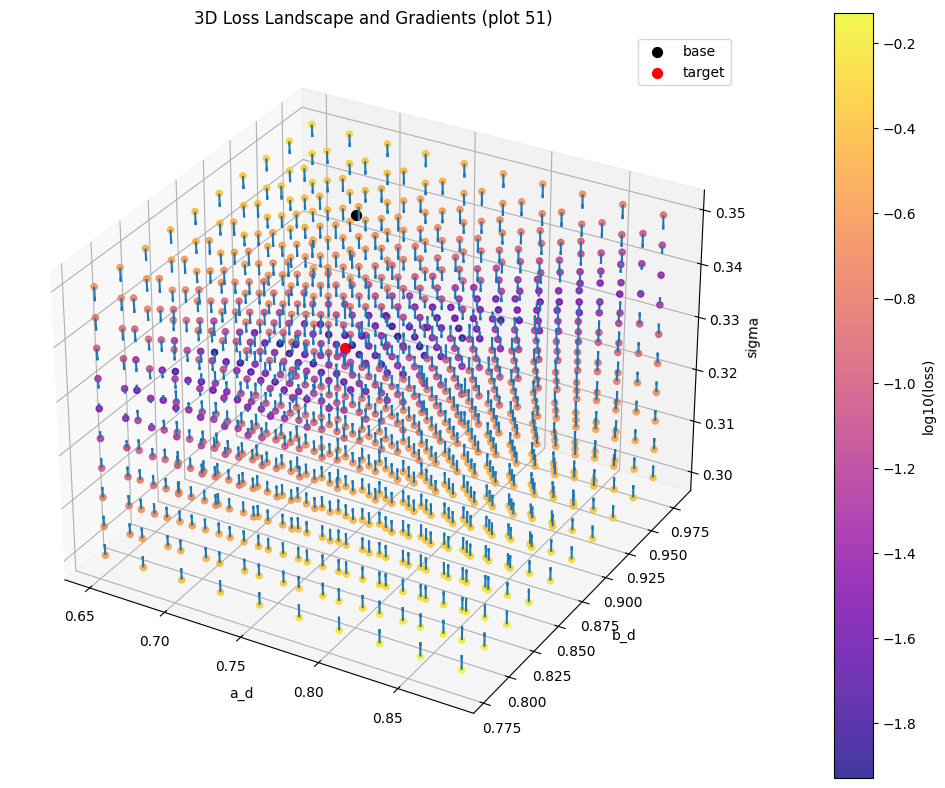

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -- Load data for the chosen plot --
plot_nm = '51'
magnitudes    = np.load(f'temp_results/Flow_map_nD/magnitudes_{plot_nm}.npy')
a_b_gradients = np.load(f'temp_results/Flow_map_nD/gradients_{plot_nm}.npy')
loss_grid     = np.load(f'temp_results/Flow_map_nD/loss_grid_{plot_nm}.npy')
mu_sigmamu    = np.load(f'temp_results/Flow_map_nD/mu_{plot_nm}.npy')
Neff          = np.load(f'temp_results/Flow_map_nD/Neff_{plot_nm}.npy')
mu, sigmamu  = mu_sigmamu[:, 0], mu_sigmamu[:, 1]
a_b_c         = np.load(f'temp_results/Flow_map_nD/ad_bd_sig_{plot_nm}.npy')

# Configuration per plot_nm: scale and base/target points
plot3d_configs = {
    '19': {'scale': 1e3, 'base': (0.68, 0.98, 0.335), 'target': (0.78, 0.88, 0.335)},
    '20': {'scale': 1e3, 'base': (0.68, 0.98, 0.335), 'target': (0.78, 0.88, 0.335)},
    '21': {'scale': 1e4, 'base': (0.68, 0.98, 0.335), 'target': (0.78, 0.88, 0.335)},
    '22': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.78, 0.88, 0.335)},
    '23': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.58, 0.88, 0.31)},
    '24': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.78, 0.88, 0.335)},
    '25': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.78, 0.88, 0.335)},
    '26': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.78, 0.88, 0.325)},
    '27': {'scale': 5e2, 'base': (0.68, 0.98, 0.335), 'target': (0.58, 0.88, 0.31)},
    '28': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.58, 0.88, 0.31)},
    '29': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.58, 0.88, 0.31)},
    '30': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.58, 0.88, 0.31)},
    '31': {'scale': 5e2, 'base': (0.68, 0.98, 0.335), 'target': (0.58, 0.88, 0.31)},
    '32': {'scale': 5e2, 'base': (0.68, 0.98, 0.335), 'target': (0.58, 0.88, 0.31)},
    '33': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.58, 0.88, 0.31)},
    '34': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.78, 0.88, 0.33)},
    '35': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.78, 0.88, 0.33)},
    '36': {'scale': 2e4, 'base': (0.68, 0.98, 0.335), 'target': (0.76, 0.98, 0.33)},
    '37': {'scale': 2e4, 'base': (0.68, 0.98, 0.335), 'target': (0.76, 0.98, 0.33)},
    '38': {'scale': 2e4, 'base': (0.68, 0.98, 0.335), 'target': (1.48, 0.98, 0.33)},
    '39': {'scale': 2e4, 'base': (0.68, 0.98, 0.335), 'target': (1.48, 0.98, 0.33)},
    '40': {'scale': 8e2, 'base': (0.68, 0.98, 0.335), 'target': (0.74, 0.88, 0.33)},
    '41': {'scale': 2e4, 'base': (0.68, 0.98, 0.335), 'target': (0.74, 0.88, 0.33)},
    '42': {'scale': 8e2, 'base': (0.68, 0.98, 0.335), 'target': (0.74, 0.88, 0.33)},
    '43': {'scale': 8e3, 'base': (0.68, 0.98, 0.335), 'target': (0.74, 0.88, 0.33)},
    '44': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.74, 0.88, 0.33)},
    '45': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.74, 0.88, 0.33)},
    '46': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.74, 0.88, 0.33)},
    '47': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.74, 0.88, 0.33)},
    '48': {'scale': 5e2, 'base': (0.68, 0.98, 0.335), 'target': (0.74, 0.88, 0.33)},
    '49': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.74, 0.88, 0.33)},
    '50': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.74, 0.88, 0.33)},
    '51': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.74, 0.88, 0.33)},
}
config = plot3d_configs.get(plot_nm)
if config is None:
    raise ValueError(f"Unsupported plot_nm: {plot_nm}")

# Unpack coordinates and gradients
ad, bd, sig = a_b_c[:, 0], a_b_c[:, 1], a_b_c[:, 2]
g1, g2, g3  = -a_b_gradients[:, 0], -a_b_gradients[:, 1], -a_b_gradients[:, 2]

# Create 3D figure
fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')

# Plot base and target
ax.scatter(*config['base'],  marker='o', color='black', s=50, label='base')
ax.scatter(*config['target'], marker='o', color='red',   s=50, label='target')

# Quiver for gradient field
ax.quiver(ad, bd, sig,
          g1 / config['scale'],
          g2 / config['scale'],
          g3 / config['scale'],
          length=1.0, normalize=False)

# Scatter colored by loss value
sc = ax.scatter(ad, bd, sig,
                c=np.log10(loss_grid), cmap='plasma',
                s=20, alpha=0.8)
cbar = fig.colorbar(sc, pad=0.1)
cbar.set_label('log10(loss)')

# Labels and legend
ax.set_xlabel('a_d')
ax.set_ylabel('b_d')
ax.set_zlabel('sigma')
ax.set_title(f'3D Loss Landscape and Gradients (plot {plot_nm})')
ax.legend()
plt.tight_layout()
plt.show()


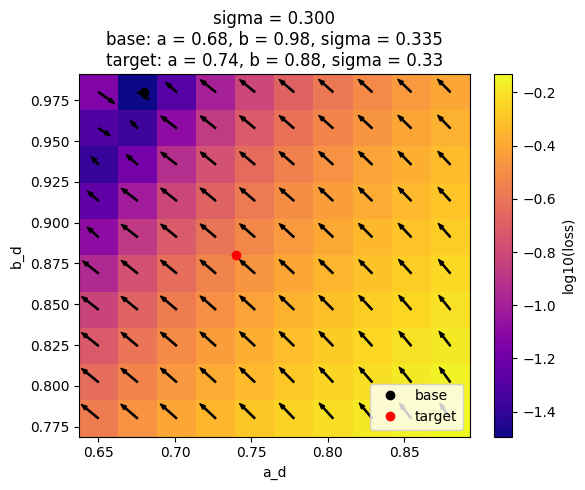

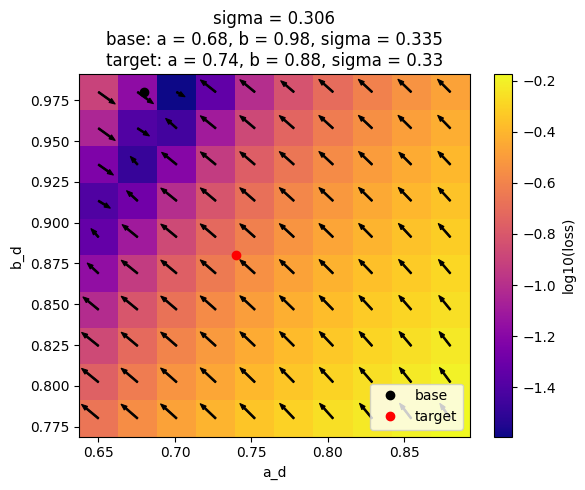

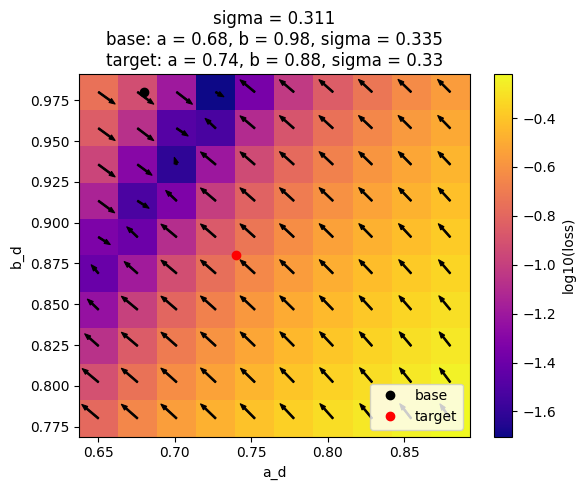

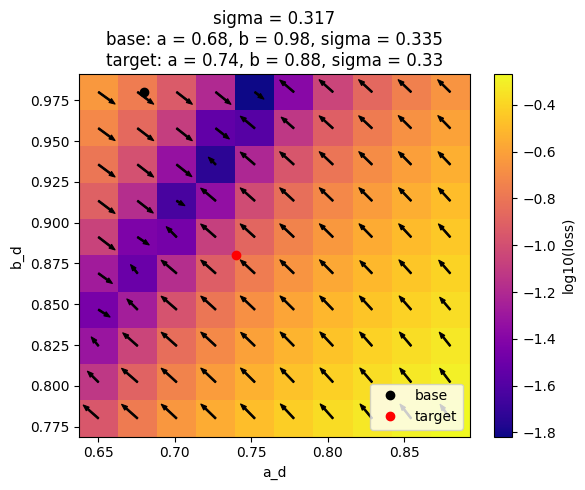

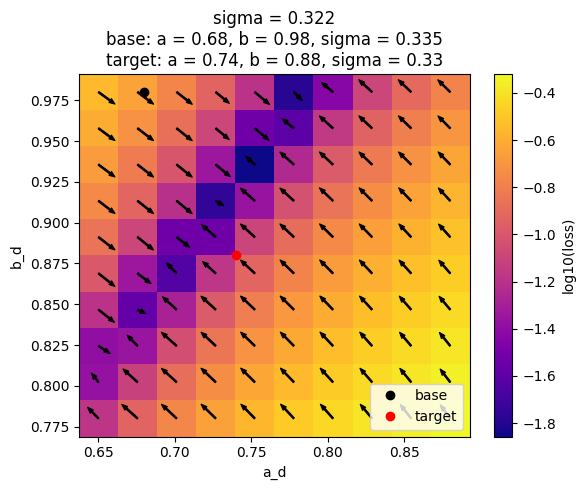

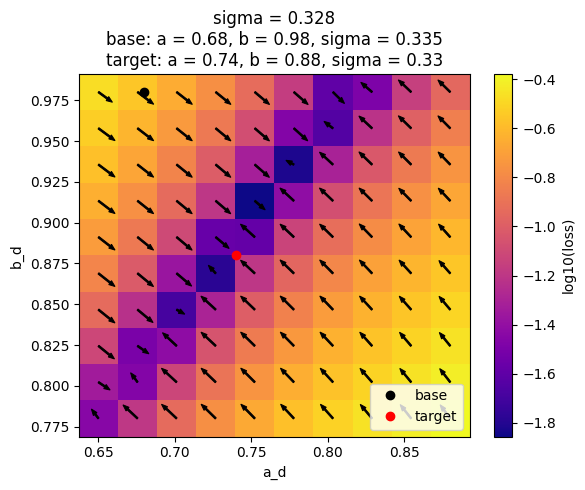

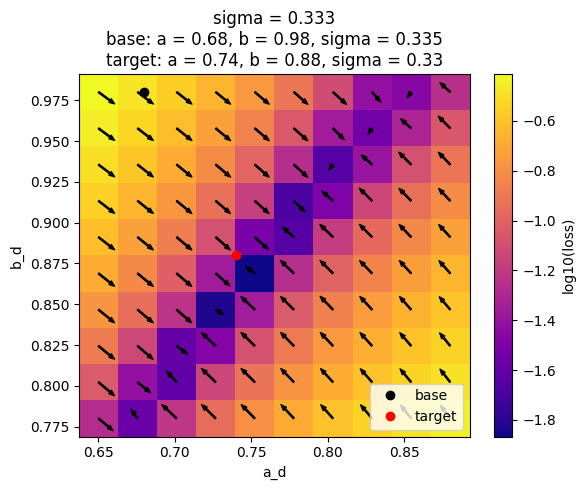

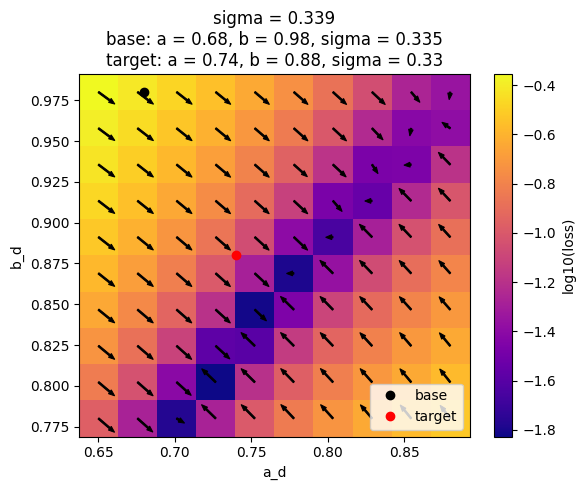

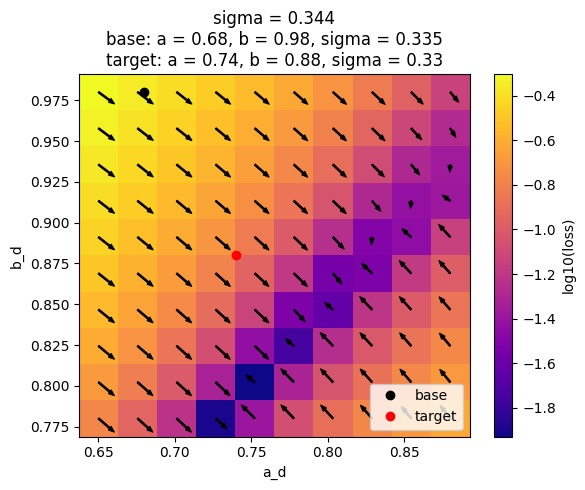

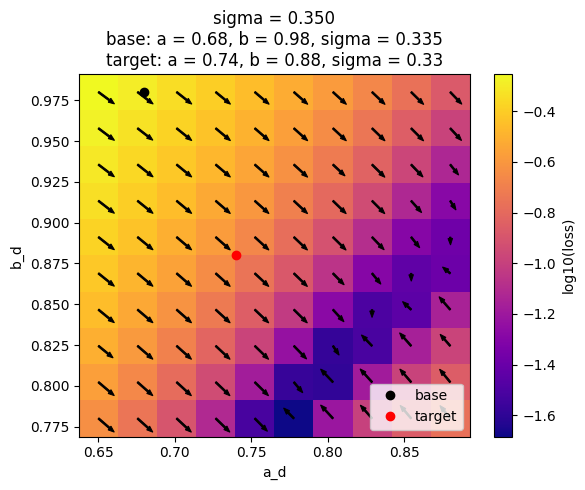

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Configuration for each plot
plot_configs = {
    '19': {'scale': 1e2, 'head_width': 0.03, 'head_length': 0.04, 'base': {'a': 0.68, 'b': 0.98, 'sigma': 0.335}, 'target': {'a': 0.78, 'b': 0.88, 'sigma': 0.335}},
    '20': {'scale': 1e2, 'head_width': 0.03, 'head_length': 0.04, 'base': {'a': 0.68, 'b': 0.98, 'sigma': 0.335}, 'target': {'a': 0.78, 'b': 0.88, 'sigma': 0.335}},
    '22': {'scale': 3e2, 'head_width': 0.003, 'head_length': 0.004, 'base': {'a': 0.68, 'b': 0.98, 'sigma': 0.335}, 'target': {'a': 0.78, 'b': 0.88, 'sigma': 0.335}},
    '23': {'scale': 3e2, 'head_width': 0.003, 'head_length': 0.004, 'base': {'a': 0.68, 'b': 0.98, 'sigma': 0.335}, 'target': {'a': 0.58, 'b': 0.88, 'sigma': 0.31}},
    '51': {'scale': 3e2, 'head_width': 0.003, 'head_length': 0.004, 'base': {'a': 0.68, 'b': 0.98, 'sigma': 0.335}, 'target': {'a': 0.74, 'b': 0.88, 'sigma': 0.33}},
}
config = plot_configs.get(plot_nm)
if config is None:
    raise ValueError(f"Unsupported plot_nm: {plot_nm}")

# Choose metric to plot
metrics = {
    'loss': {'values': lambda: np.log10(loss_grid), 'label': 'log10(loss)'},
    'mu':   {'values': lambda: mu, 'label': r"$\ln\left|\frac{1-\mu}{\sigma_{1-\mu}}\right|$"},
    'Neff': {'values': lambda: Neff, 'label': 'Neff'},
}
metric_key = 'loss'
metric = metrics[metric_key]

# Extract unique sigma slices (a_u values)
au_vals = np.unique(a_b_c[:, 2])

for au_val in au_vals:
    plt.figure(figsize=(6, 5))
    
    # Slice data for fixed sigma
    mask = a_b_c[:, 2] == au_val
    ad = a_b_c[mask, 0]
    bd = a_b_c[mask, 1]
    ad_bd = np.vstack([ad, bd]).T
    grads = a_b_gradients[mask]
    metric_vals = metric['values']()[mask]

    # Make mesh grid
    ad_unique = np.unique(ad)
    bd_unique = np.unique(bd)
    A, B = np.meshgrid(ad_unique, bd_unique, indexing='ij')
    Z = metric_vals.reshape(len(ad_unique), len(bd_unique))

    # Plot heatmap
    pcm = plt.pcolormesh(A, B, Z, shading='auto', cmap='plasma')
    plt.colorbar(pcm, label=metric['label'])

    # Plot gradient arrows
    for (x, y), g in zip(ad_bd, grads):
        plt.arrow(x, y, -g[0] / config['scale'], -g[1] / config['scale'],
                  head_width=config['head_width'], head_length=config['head_length'], fc='k', ec='k', linewidth=0.7)

    # Base and target points
    base = config['base']
    tgt = config['target']
    plt.plot(base['a'], base['b'], 'o', color='black', markersize=6, label='base')
    plt.plot(tgt['a'], tgt['b'], 'o', color='red', markersize=6, label='target')

    # Title and labels
    plt.title(
        f"sigma = {au_val:.3f}\n"
        f"base: a = {base['a']}, b = {base['b']}, sigma = {base['sigma']}\n"
        f"target: a = {tgt['a']}, b = {tgt['b']}, sigma = {tgt['sigma']}"
    )
    plt.xlabel('a_d')
    plt.ylabel('b_d')
    plt.legend(loc='lower right')
    plt.tight_layout()
    # plt.savefig(f'temp_results/Flow_map_nD/plots/sig3_{plot_nm}_{au_val:.4f}.png')
    plt.show()


/tmp/ipykernel_2152625/133748945.py:67: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6,5))


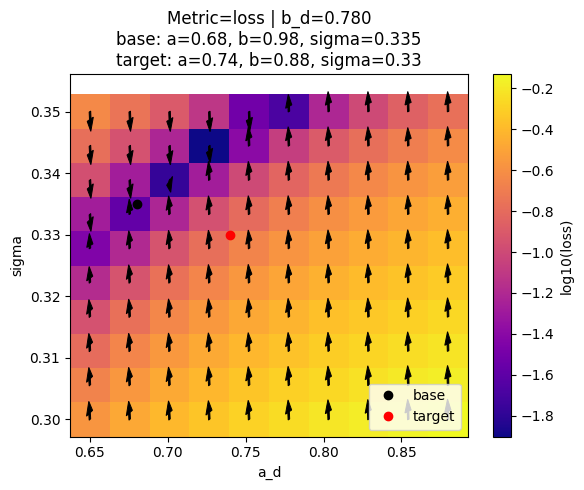

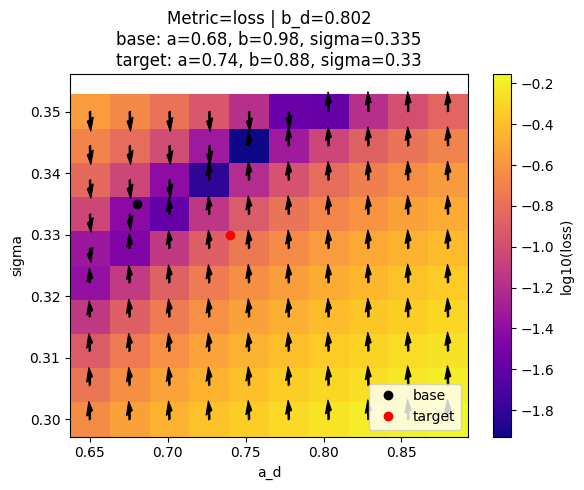

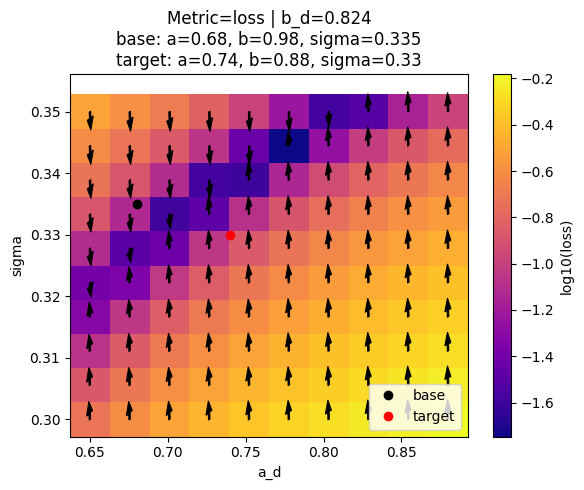

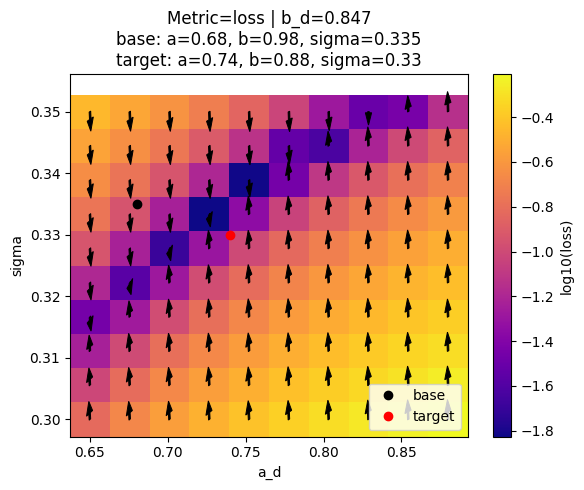

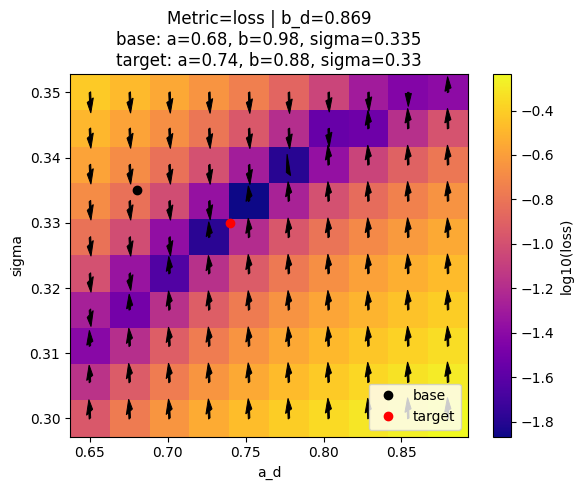

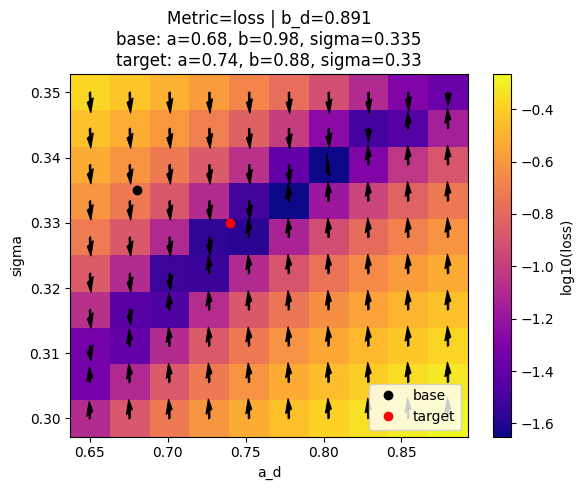

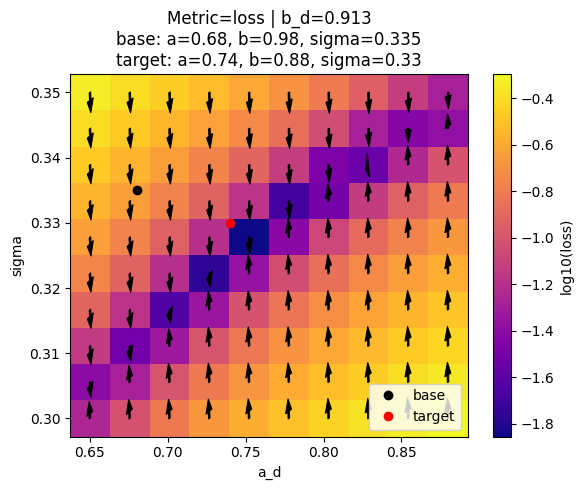

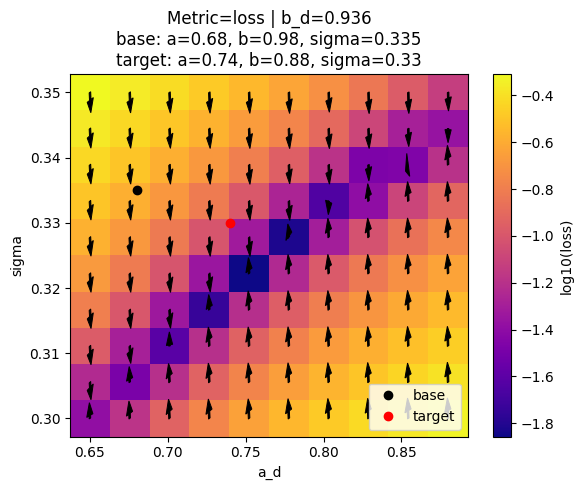

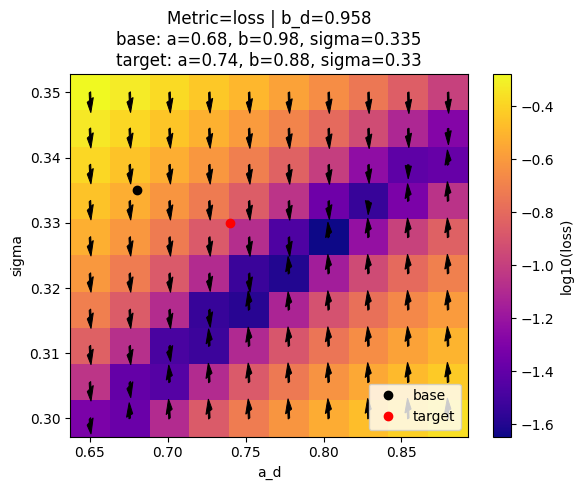

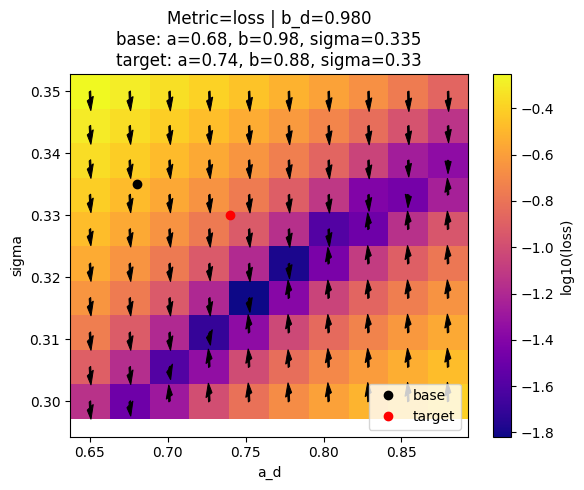

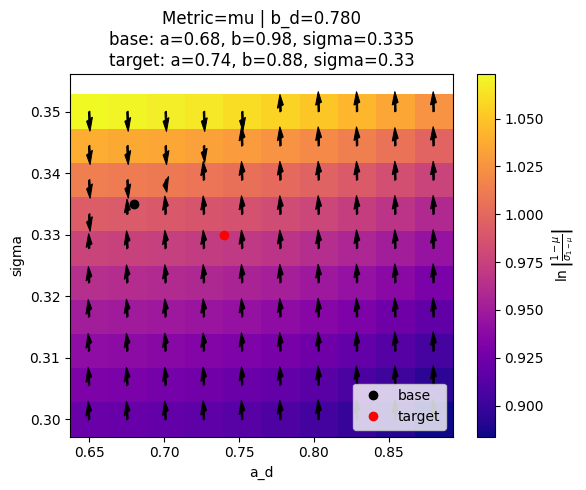

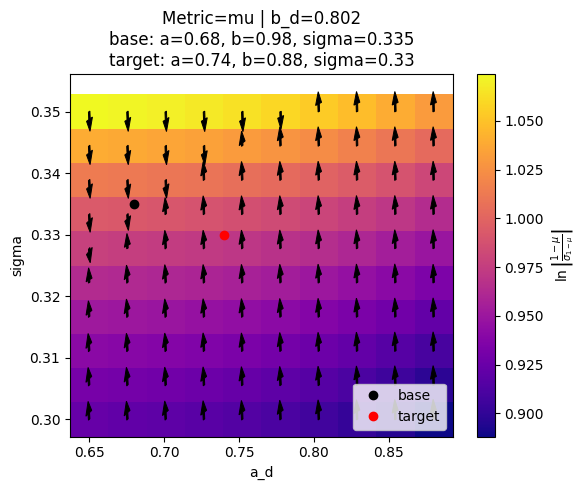

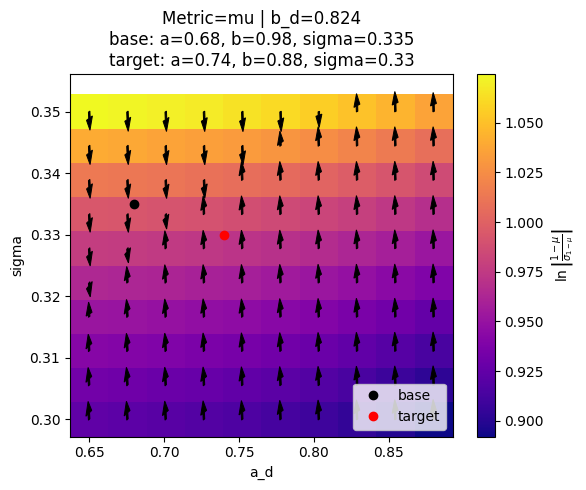

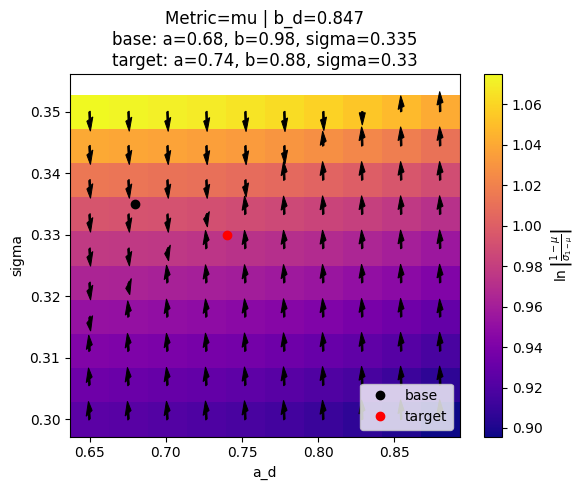

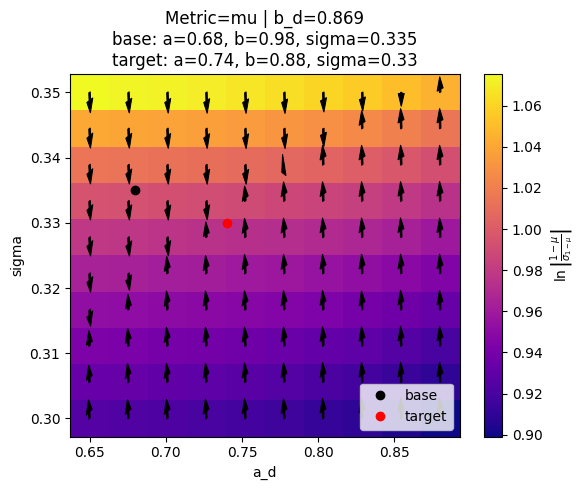

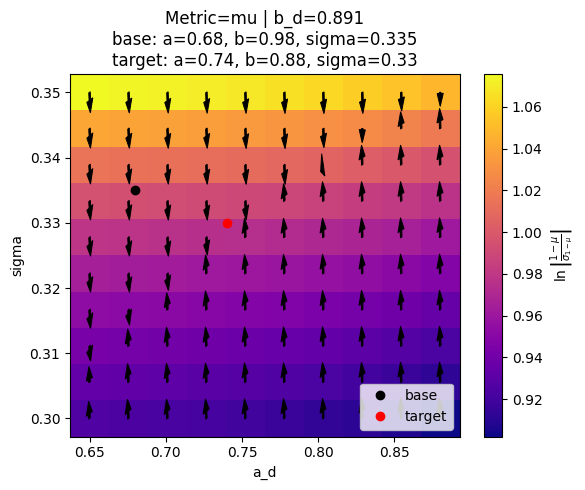

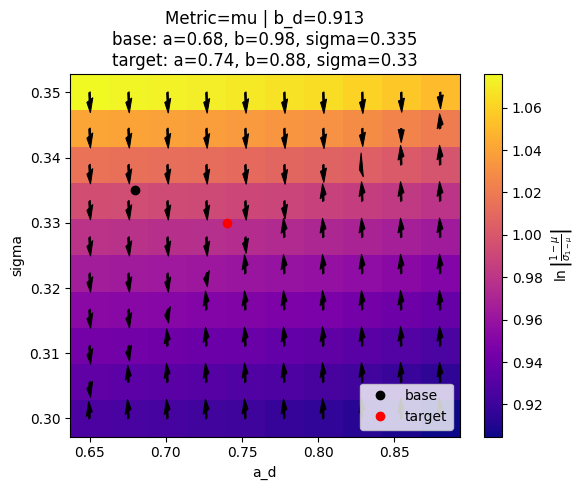

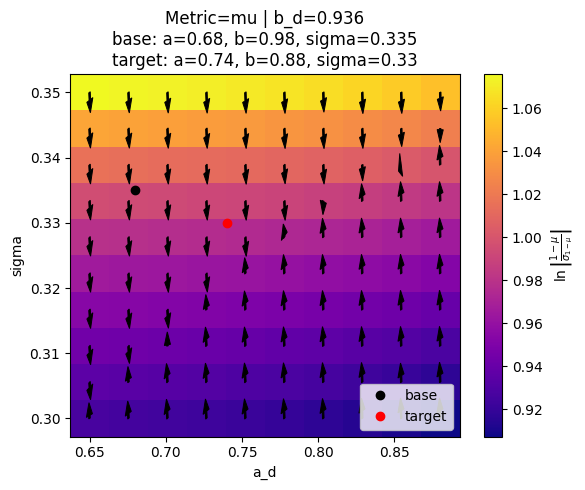

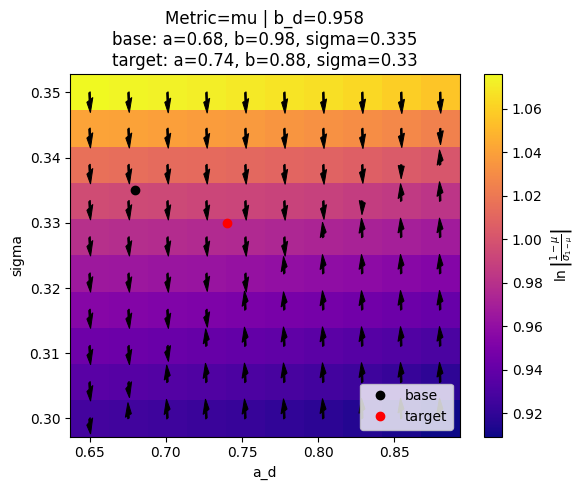

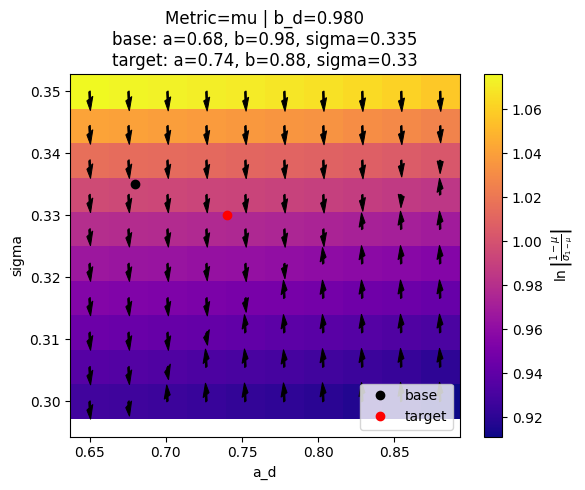

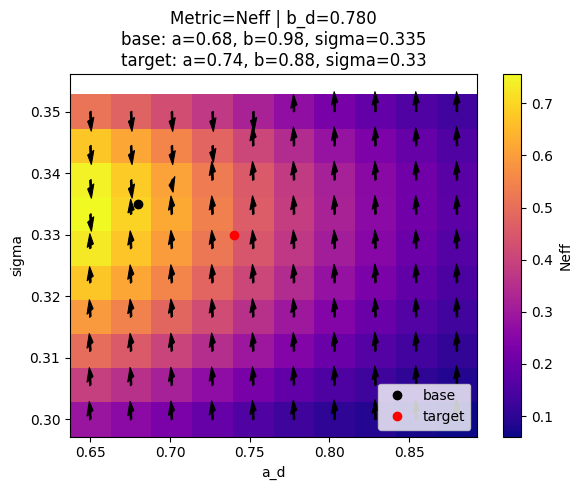

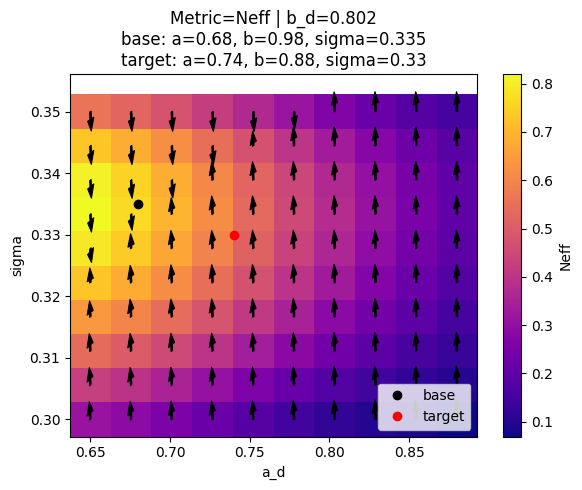

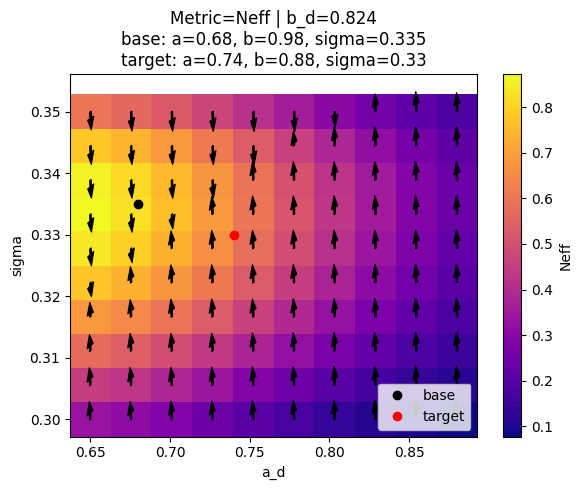

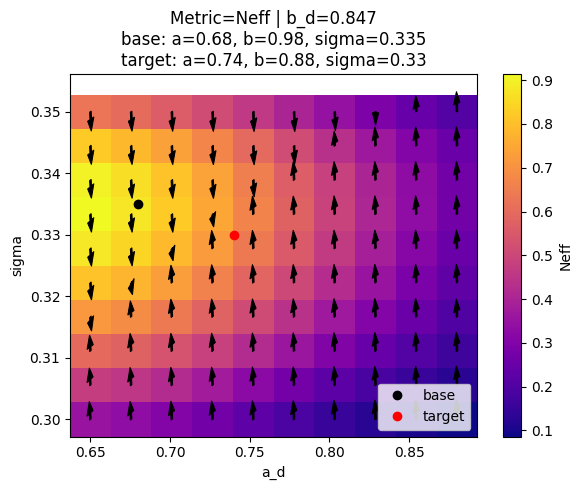

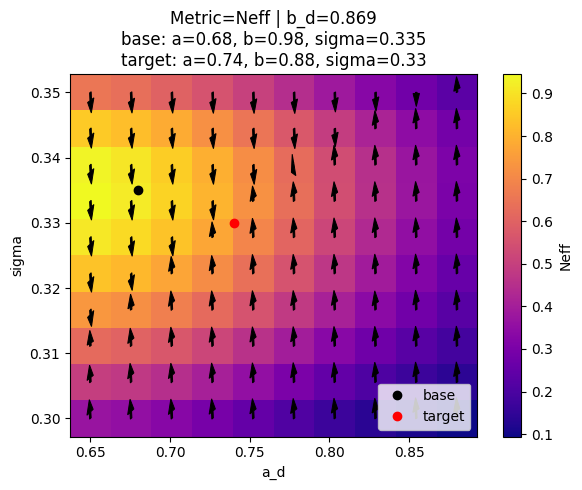

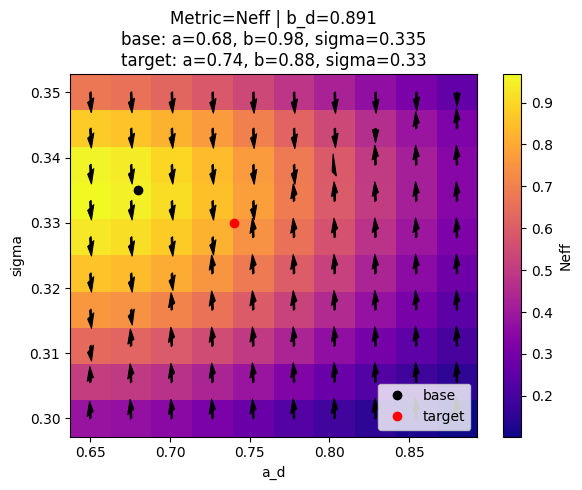

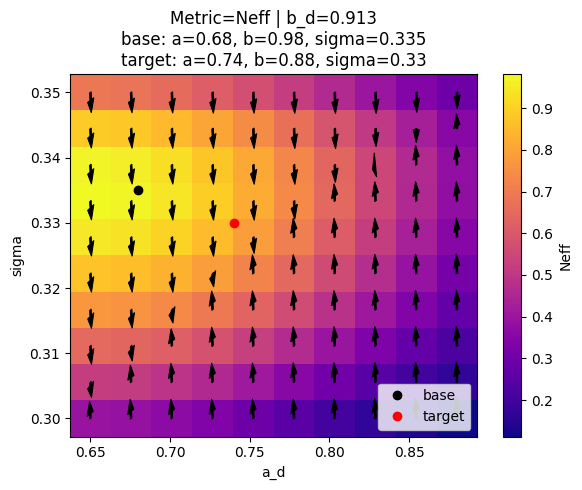

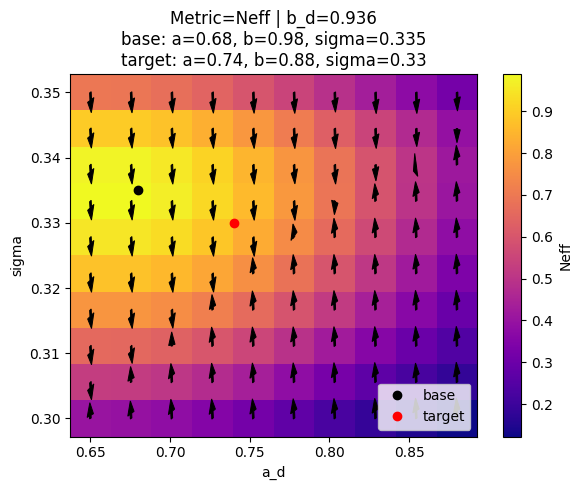

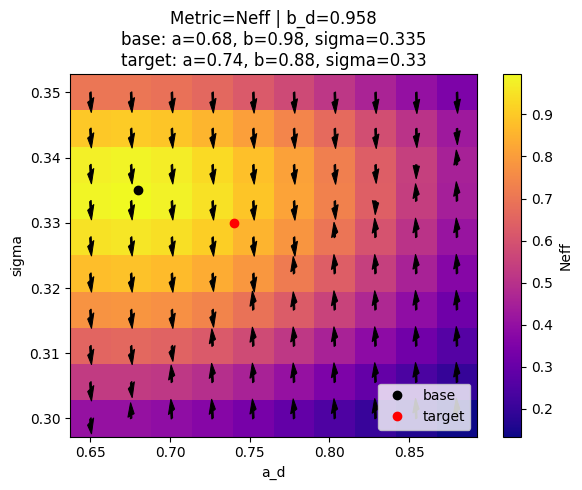

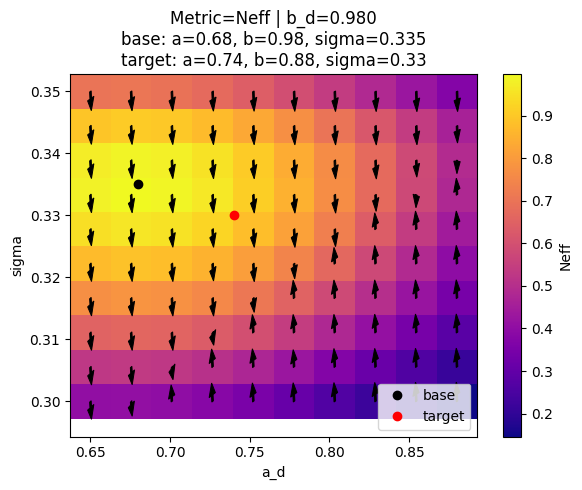

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Configuration per plot_nm: scale, head_width, head_length, base (a,b,sigma), target (a,b,sigma)
plot_configs = {
    '21':{'scale':3e3,'head_width':0.003,'head_length':0.003,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.78,'b':0.88,'sigma':0.335}},
    '22':{'scale':3e3,'head_width':0.003,'head_length':0.003,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.78,'b':0.88,'sigma':0.335}},
    '23':{'scale':8e3,'head_width':0.003,'head_length':0.003,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.58,'b':0.88,'sigma':0.31}},
    '24':{'scale':8e3,'head_width':0.003,'head_length':0.001,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.78,'b':0.98,'sigma':0.325}},
    '25':{'scale':8e3,'head_width':0.003,'head_length':0.001,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.78,'b':0.98,'sigma':0.325}},
    '26':{'scale':8e3,'head_width':0.003,'head_length':0.001,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.78,'b':0.88,'sigma':0.325}},
    '27':{'scale':8e2,'head_width':0.003,'head_length':0.001,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.58,'b':0.88,'sigma':0.31}},
    '29':{'scale':4e3,'head_width':0.003,'head_length':0.001,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.58,'b':0.88,'sigma':0.31}},
    '30':{'scale':4e3,'head_width':0.003,'head_length':0.001,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.58,'b':0.88,'sigma':0.31}},
    '31':{'scale':4e3,'head_width':0.003,'head_length':0.001,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.58,'b':0.88,'sigma':0.31}},
    '32':{'scale':4e3,'head_width':0.003,'head_length':0.001,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.58,'b':0.88,'sigma':0.31}},
    '33':{'scale':4e3,'head_width':0.003,'head_length':0.001,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.58,'b':0.88,'sigma':0.31}},
    '34':{'scale':8e3,'head_width':0.0003,'head_length':0.0003,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.78,'b':0.88,'sigma':0.33}},
    '35':{'scale':1e4,'head_width':0.0003,'head_length':0.0003,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.78,'b':0.88,'sigma':0.33}},
    '36':{'scale':1e4,'head_width':0.0003,'head_length':0.0003,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.76,'b':0.98,'sigma':0.33}},
    '37':{'scale':1e4,'head_width':0.0003,'head_length':0.0003,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.76,'b':0.98,'sigma':0.33}},
    '38':{'scale':6e3,'head_width':0.0006,'head_length':0.003,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':1.48,'b':0.98,'sigma':0.33}},
    '39':{'scale':1e3,'head_width':0.0003,'head_length':0.0003,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':1.48,'b':0.98,'sigma':0.33}},
    '40':{'scale':5e3,'head_width':0.009,'head_length':0.004,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.74,'b':0.88,'sigma':0.33}},
    '41':{'scale':1e3,'head_width':0.003,'head_length':0.003,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.74,'b':0.88,'sigma':0.33}},
    '42':{'scale':10e2,'head_width':0.006,'head_length':0.006,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.74,'b':0.88,'sigma':0.33}},
    '43':{'scale':10e3,'head_width':0.004,'head_length':0.002,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.74,'b':0.88,'sigma':0.33}},
    '44':{'scale':10e3,'head_width':0.004,'head_length':0.002,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.74,'b':0.88,'sigma':0.33}},
    '45':{'scale':10e3,'head_width':0.004,'head_length':0.002,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.74,'b':0.88,'sigma':0.33}},
    '46':{'scale':10e3,'head_width':0.004,'head_length':0.002,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.74,'b':0.88,'sigma':0.33}},
    '47':{'scale':10e3,'head_width':0.004,'head_length':0.002,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.74,'b':0.88,'sigma':0.33}},
    '48':{'scale':5e2,'head_width':0.004,'head_length':0.002,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.74,'b':0.88,'sigma':0.33}},
    '49':{'scale':10e3,'head_width':0.004,'head_length':0.002,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.74,'b':0.88,'sigma':0.33}},
    '50':{'scale':10e3,'head_width':0.004,'head_length':0.002,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.74,'b':0.88,'sigma':0.33}},
    '51':{'scale':10e3,'head_width':0.004,'head_length':0.002,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.74,'b':0.88,'sigma':0.33}},
}
config = plot_configs.get(plot_nm)
if config is None:
    raise ValueError(f"Unsupported plot_nm: {plot_nm}")

# Metrics to display
metrics = {
    'loss': {'values': lambda: np.log10(loss_grid), 'label': 'log10(loss)'},
    'mu':   {'values': lambda: mu,               'label': r"$\ln\left|\frac{1-\mu}{\sigma_{1-\mu}}\right|$"},
    'Neff': {'values': lambda: Neff,             'label': 'Neff'},
}

# Unique bd values to slice
bds = np.unique(a_b_c[:,1])

for metric_key, metric in metrics.items():
    vals = metric['values']()
    for bd_val in bds:
        mask = (a_b_c[:,1] == bd_val)
        ad_vals = a_b_c[mask,0]
        au_vals = a_b_c[mask,2]
        grads   = a_b_gradients[mask]
        m_vals  = vals[mask]

        # Build grid
        ad_u = np.unique(ad_vals)
        au_u = np.unique(au_vals)
        A, U = np.meshgrid(ad_u, au_u, indexing='ij')
        Z    = m_vals.reshape(len(ad_u), len(au_u))

        # Plot
        plt.figure(figsize=(6,5))
        pcm = plt.pcolormesh(A, U, Z, shading='auto', cmap='plasma')
        plt.colorbar(pcm, label=metric['label'])

        # Gradient arrows
        for (x,y), g in zip(np.vstack([ad_vals, au_vals]).T, grads):
            dx = -g[0] / config['scale']
            dy = -g[2] / config['scale']
            plt.arrow(x, y, dx, dy,
                      head_width=config['head_width'],
                      head_length=config['head_length'],
                      fc='k', ec='k', linewidth=0.7)

        # Base and target markers
        base = config['base']
        tgt  = config['target']
        plt.plot(base['a'], base['sigma'], 'o', color='black', markersize=6, label='base')
        plt.plot(tgt['a'],  tgt['sigma'],'o', color='red',   markersize=6, label='target')

        # Title uses base/target b and sigma
        title = (
            f"Metric={metric_key} | b_d={bd_val:.3f}\n"
            f"base: a={base['a']}, b={base['b']}, sigma={base['sigma']}\n"
            f"target: a={tgt['a']}, b={tgt['b']}, sigma={tgt['sigma']}"
        )
        plt.title(title)
        plt.xlabel('a_d')
        plt.ylabel('sigma')
        plt.legend(loc='lower right')
        plt.tight_layout()
        # plt.savefig(f'temp_results/Flow_map_nD/plots/{plot_nm}_{metric_key}_bd_{bd_val:.3f}.png', dpi=300)


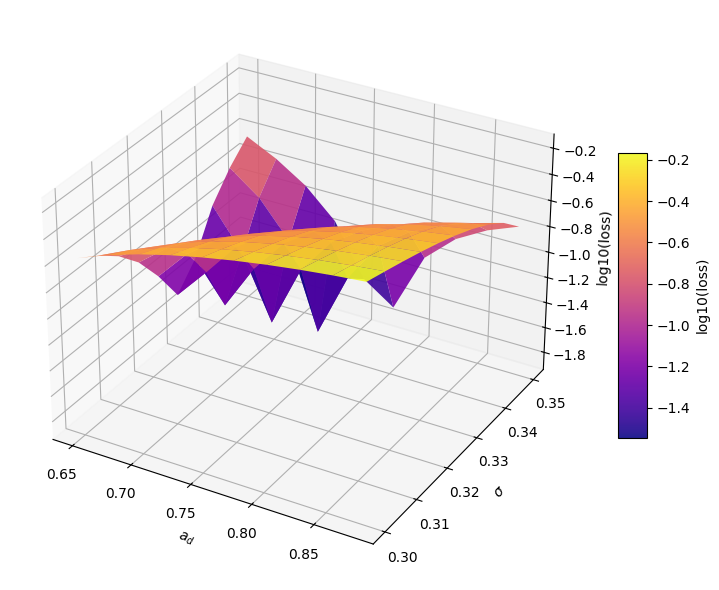

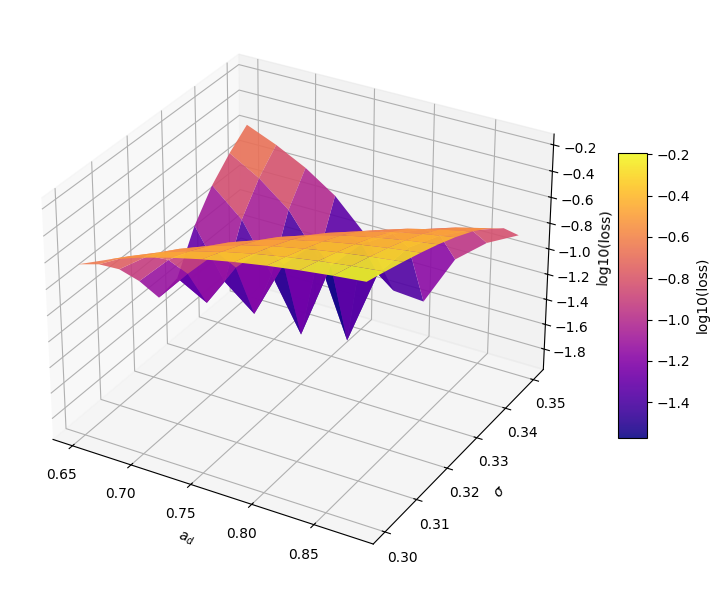

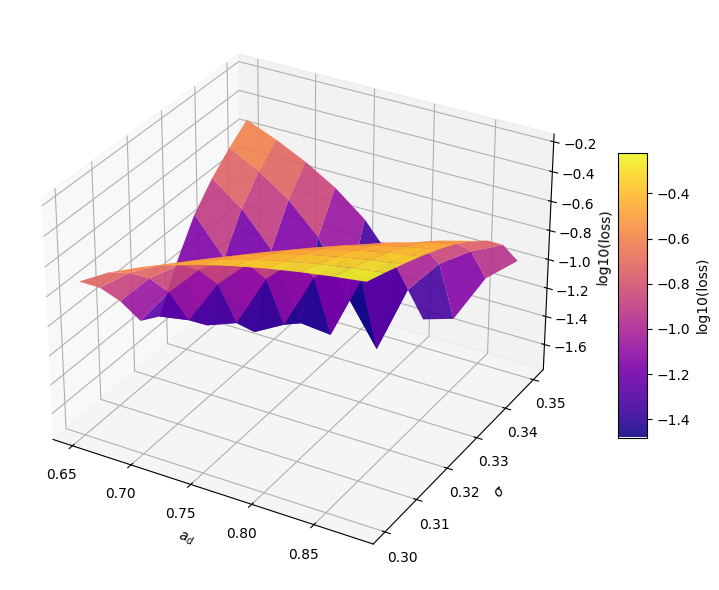

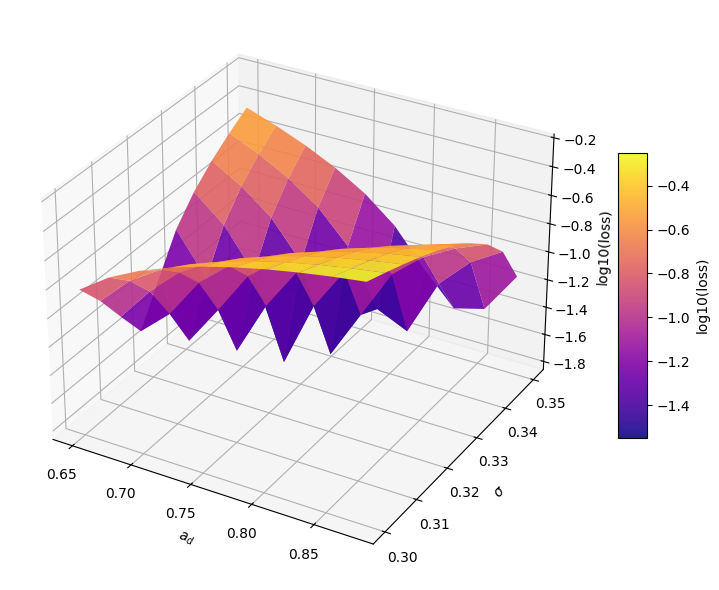

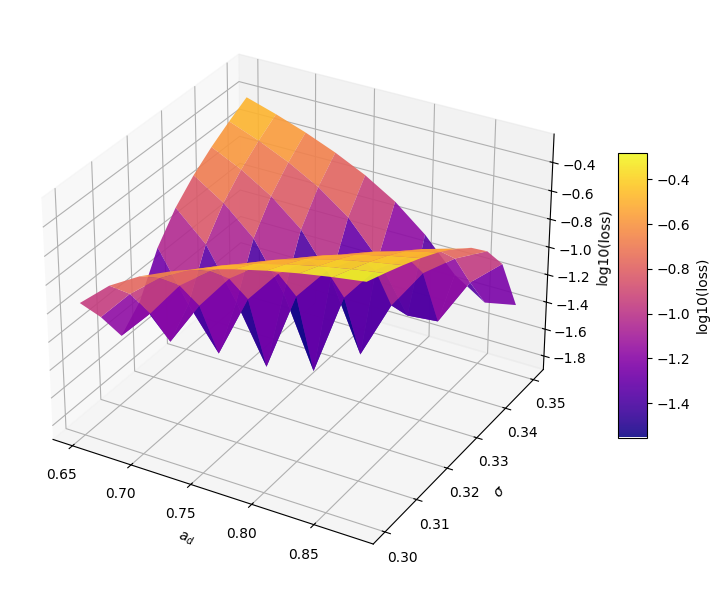

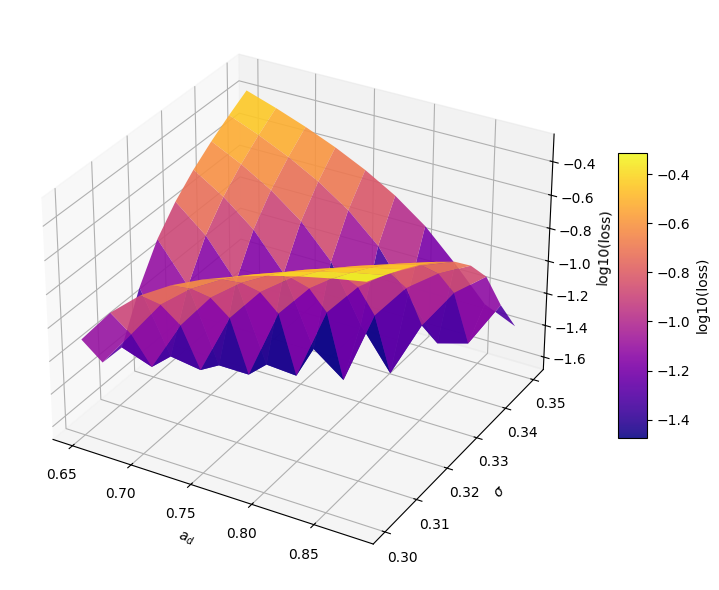

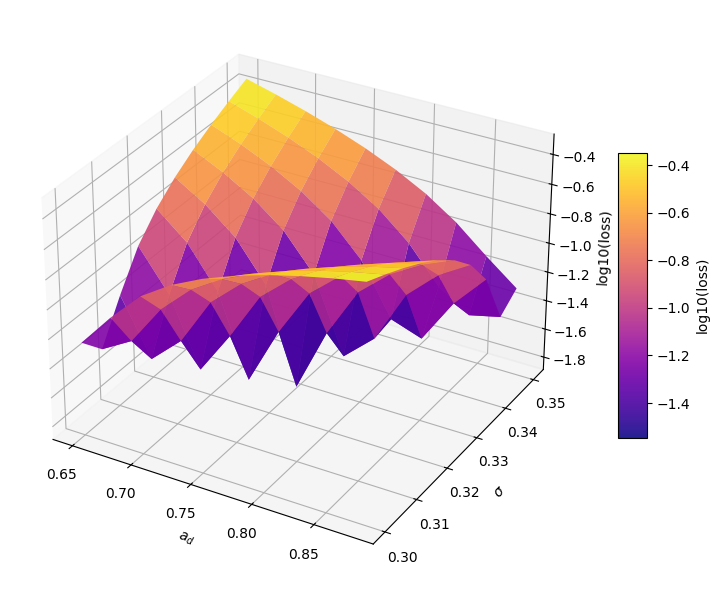

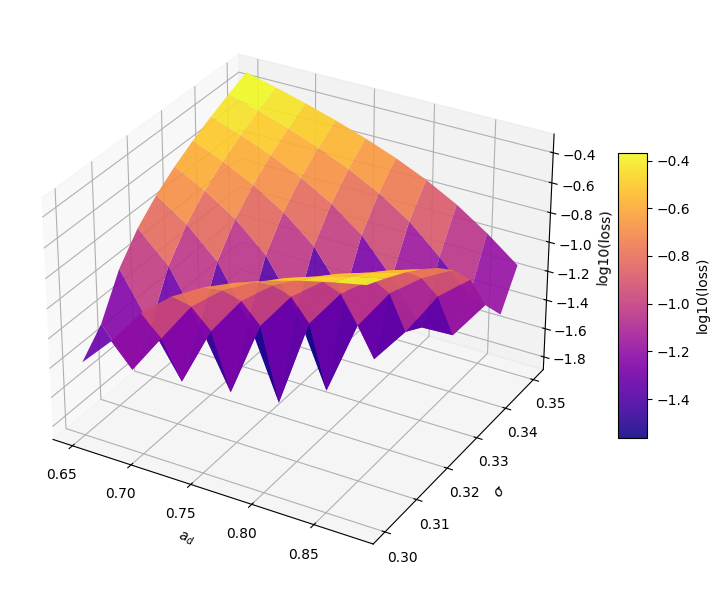

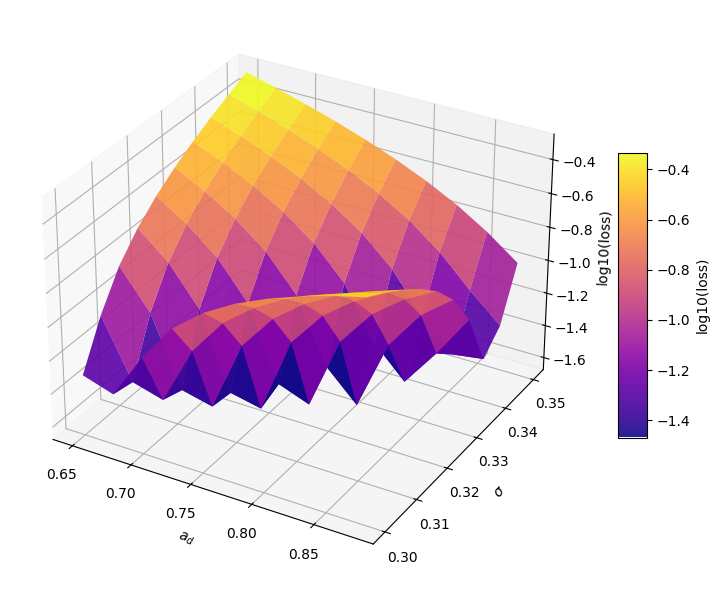

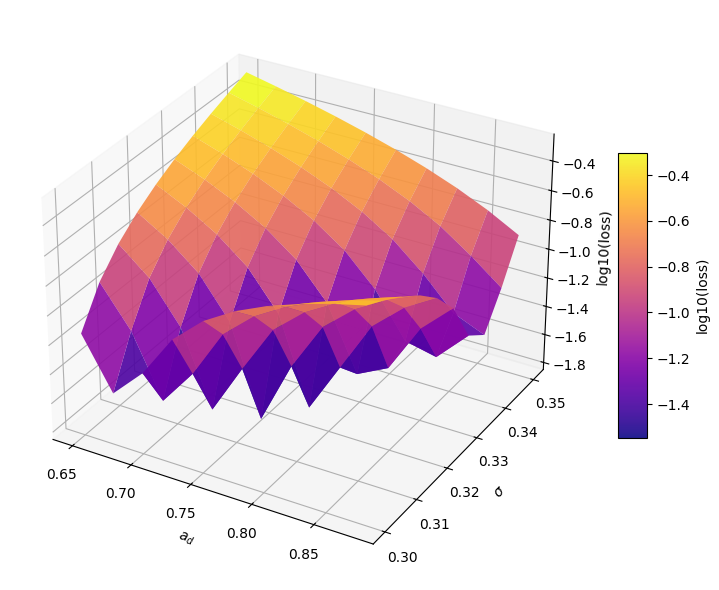

In [22]:



import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  

bds = np.unique(a_b_c[:, 1])
scale = 3e3

for b_value in bds:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    # Mask for current b_value
    mask = a_b_c[:, 1] == b_value
    ad = a_b_c[mask, 0]
    au = a_b_c[mask, 2]
    a_b_grad_plot = a_b_gradients[mask]
    loss_plot = np.log10(loss_grid[mask])

    # Create 2D grid
    ad_unique = np.unique(ad)
    au_unique = np.unique(au)
    ad_grid, au_grid = np.meshgrid(ad_unique, au_unique, indexing='ij')
    loss_2d = loss_plot.reshape(len(ad_unique), len(au_unique))

    # Surface plot
    surf = ax.plot_surface(ad_grid, au_grid, loss_2d, cmap='plasma', alpha=0.9)
    fig.colorbar(surf, shrink=0.5, aspect=10, label='log10(loss)')

    # Arrows (optional)
    if plot_nm == '22':
        for point, gradient in zip(np.vstack([ad, au]).T, a_b_grad_plot):
            ax.quiver(point[0], point[1],  # x, y
                      loss_plot[0],        # z base
                      -gradient[0]/scale,  # dx
                      -gradient[2]/scale,  # dy
                      0,                   # dz (optional, or compute ∂L/∂z if available)
                      color='k', linewidth=0.8, arrow_length_ratio=0.15)

        ax.scatter(0.68, 0.335, np.min(loss_plot), color='red', s=50, label='base')
        ax.scatter(0.78, 0.335, np.min(loss_plot), color='black', s=50, label='target')
        ax.set_title(f'sigma = {b_value:.3f}\nbase/target trajectory')
        ax.legend()

    ax.set_xlabel(r'$a_d$')
    ax.set_ylabel(r'$\sigma$')
    ax.set_zlabel('log10(loss)')
    plt.tight_layout()
    plt.show()
    # plt.savefig(f'temp_results/Flow_map_nD/plots/39sigma3d.png')
